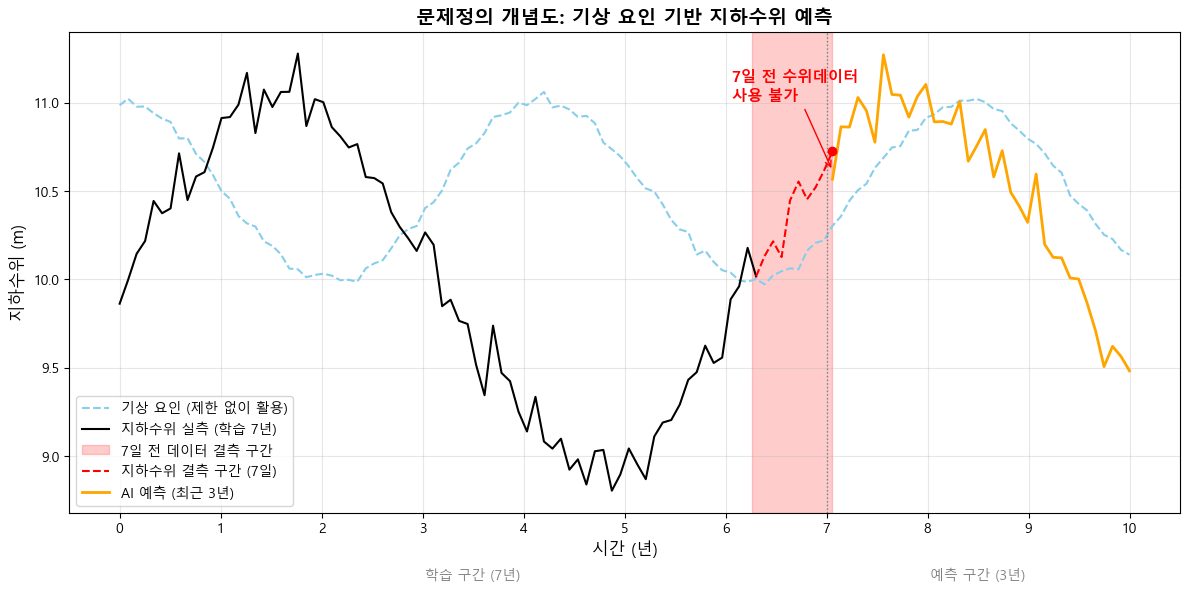

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

# 한글 폰트 설정 (나눔고딕 등)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 시간축 (10년: 7년 학습 + 3년 예측)
time = np.linspace(0, 10, 120)  # 120 points representing months (simplified)

# 실제 수위 (관측치 7년)
observed = np.sin(time) + np.random.normal(0, 0.1, len(time)) + 10

# 기상 데이터 (강수/기온 영향)
weather = 0.5*np.cos(time*1.5) + 0.2*np.random.normal(0,0.1,len(time)) + 10.5

# 예측 (3년)
predicted = np.sin(time) + np.random.normal(0, 0.1, len(time)) +10
predicted[0:84] = np.nan  # 7년차까지는 예측하지 않음

# "7일간 실측 없음" 표현
missing_obs = observed.copy()
missing_obs[84:85] = np.nan

missing_idx = 84

# 플롯
plt.figure(figsize=(12,6))

# 기상 데이터 (예측선)
plt.plot(time, weather, linestyle="--", color="skyblue", label="기상 요인 (제한 없이 활용)")

# 실제 관측선 (7년간)
plt.plot(time[0:76], observed[0:76], color="black", linewidth=1.5, label="지하수위 실측 (학습 7년)")

# 결측 강조: 빨간 음영 영역

plt.axvspan(time[missing_idx]-0.8, time[missing_idx], 
            color="red", alpha=0.2, label="7일 전 데이터 결측 구간")

# 결측 주석
plt.annotate("7일 전 수위데이터\n사용 불가",
             xy=(time[missing_idx], observed[missing_idx-1]),
             xytext=(time[missing_idx]-1.0, observed[missing_idx-1]+0.4),  # 위치 조정
             arrowprops=dict(arrowstyle="->", color="red"),
             fontsize=11, color="red", weight="bold")


# 결측 부분 (7일 없음)
plt.scatter(time[84:85], observed[84:85], color="red", zorder=5)
plt.plot(time[75:85], observed[75:85], linestyle="--", color="red", label="지하수위 결측 구간 (7일)", zorder=5)

# 예측선 (3년간)
plt.plot(time, predicted, color="orange", linewidth=2, label="AI 예측 (최근 3년)")

# 구간 구분선
plt.axvline(x=7, color="gray", linestyle=":", linewidth=1)
#plt.text(3.5, 12, "학습 구간 (7년)", ha="center", fontsize=10, color="gray")
#plt.text(8.5, 12, "예측 구간 (3년)", ha="center", fontsize=10, color="gray")

plt.text(3.5, observed.min()-0.5, "학습 구간 (7년)", ha="center", fontsize=10, color="gray")
plt.text(8.5, observed.min()-0.5, "예측 구간 (3년)", ha="center", fontsize=10, color="gray")

# x축 눈금 0~10까지 1 단위
plt.xticks(np.arange(0, 11, 1))

# 스타일
plt.title("문제정의 개념도: 기상 요인 기반 지하수위 예측", fontsize=14, weight="bold")
plt.xlabel("시간 (년)", fontsize=12)
plt.ylabel("지하수위 (m)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
